# Figure 3b - Uphill mutational step overlap analysis for each 'strong' model (affinity-only, antigen capture, and competitive capture)

Loading edge CSVs...
  affinity              : mean uphill edges = 34,463
  antigen capture       : mean uphill edges = 33,406
  competitive capture   : mean uphill edges = 34,138

Overlap summary (mean ± SEM):
  A_only      : 4,037.8 ± 8.0
  B_only      : 1,751.4 ± 12.7
  C_only      : 3,233.5 ± 8.5
  AB_only     : 3,993.0 ± 11.1
  AC_only     : 3,243.3 ± 9.4
  BC_only     : 4,472.7 ± 14.6
  ABC         : 23,188.6 ± 23.9

✓ Saved S_Figure_3b.pdf


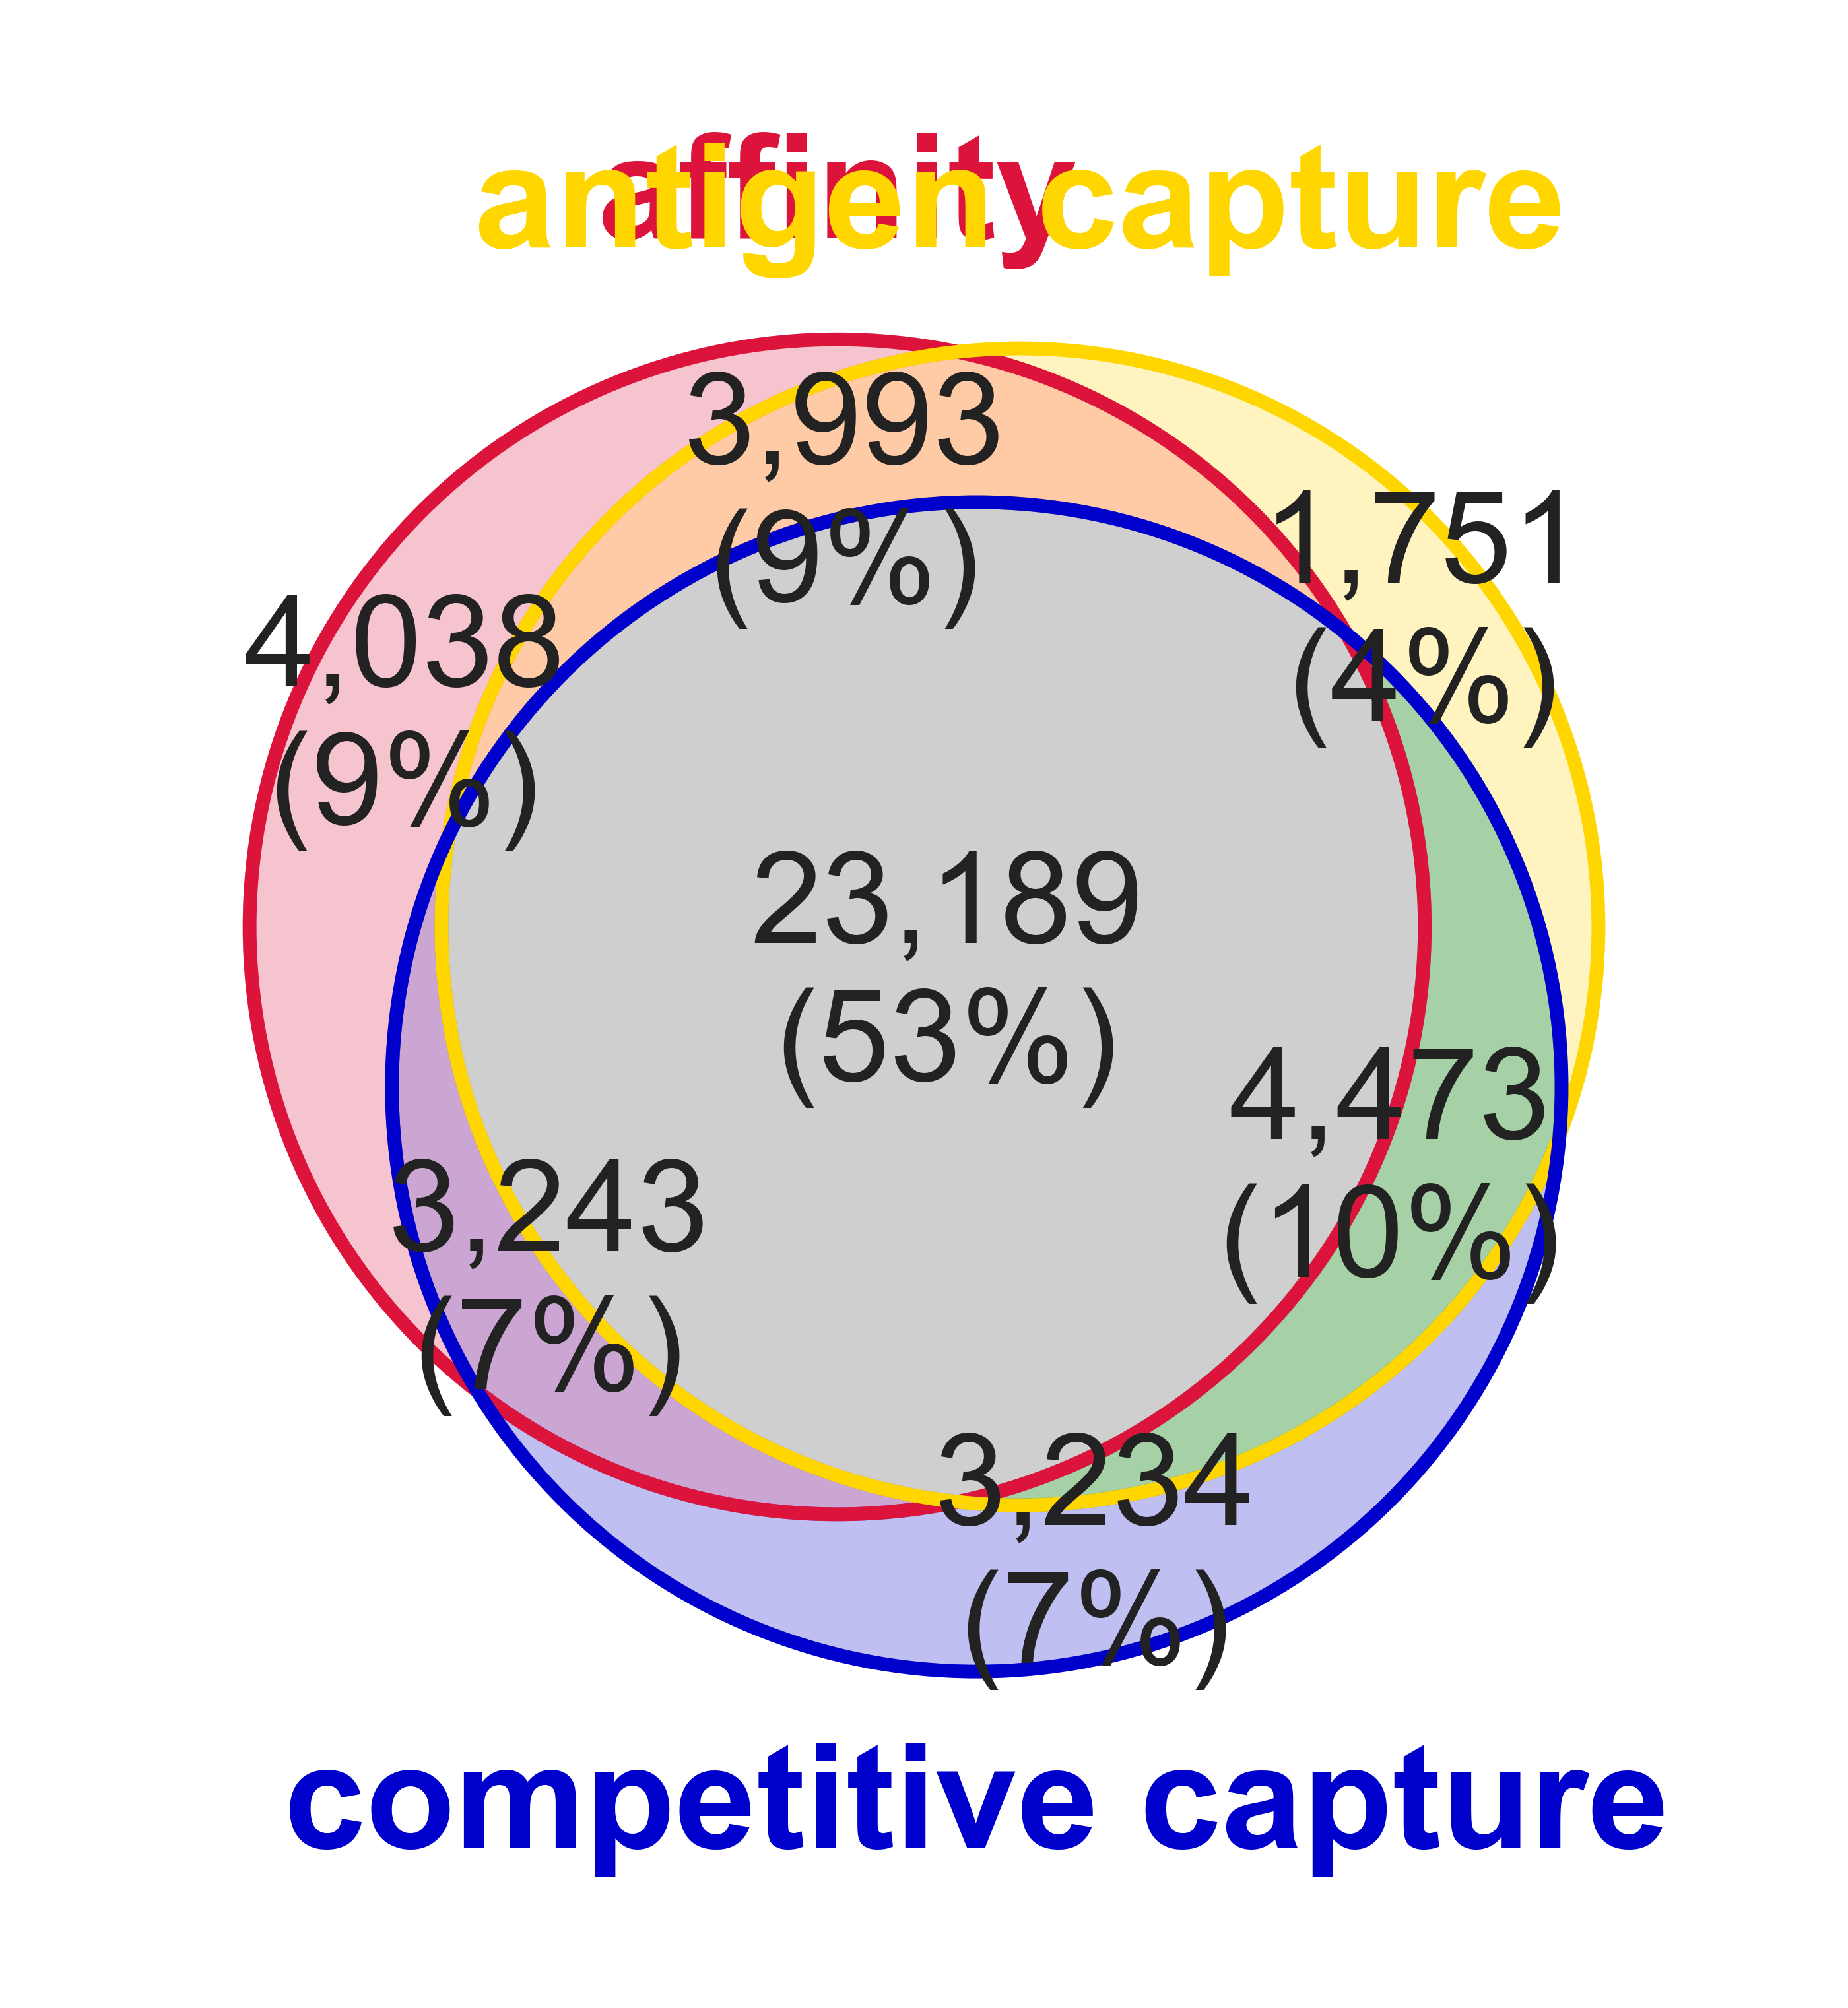

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib_venn import venn3, venn3_circles
import os

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
mpl.rcParams['figure.dpi'] = 2000
plt.rcParams.update({
    'font.size': 7,
    'axes.linewidth': 0.5,
    'xtick.major.size': 2, 'xtick.major.width': 0.5,
    'ytick.major.size': 2, 'ytick.major.width': 0.5,
})

# Configuration
ANTIBODY   = 'omi-32'
SCENARIO   = 'ba1_only'
SELECTION  = 'strong'
NBOOTSTRAP = 10

DIR_AFF  = '../../pathway_analysis/affinity_only/strong_data'
DIR_CAP  = '../../pathway_analysis/antigen_capture/strong_norm_data'
DIR_COMP = '../../pathway_analysis/competitive_antigen_capture/strong_norm_data'

MODEL_NAMES  = ['affinity', 'capture', 'competitive_capture']
MODEL_LABELS = ['affinity', 'antigen capture', 'competitive capture']
COLORS       = ['#DC143C', '#FFD600', '#0000CD']

ALPHA_SINGLE = 0.25
ALPHA_PAIR   = 0.35
ALPHA_TRIPLE = 0.4

# load uphill-path mutational steps for each of the 10 bootstraps (where bootstraps sampled a normal distribution of each predicted dataset value based on the propagated prediction error)
def load_uphill_sets(directory, model_name, nb):
    fn = (f"{directory}/{ANTIBODY}_edges_{SCENARIO}"
          f"_{model_name}_{SELECTION}_bootstrap{nb}.csv")
    df = pd.read_csv(fn)
    uphill = df[df['is_uphill'] == 1]
    return frozenset(zip(uphill['from_genotype'], uphill['to_genotype']))

# load data
print("Loading edge CSVs...")
sets = {label: [] for label in MODEL_LABELS}

for label, directory, model_name in zip(MODEL_LABELS, [DIR_AFF, DIR_CAP, DIR_COMP], MODEL_NAMES):
    for nb in range(NBOOTSTRAP):
        sets[label].append(load_uphill_sets(directory, model_name, nb))
    n_mean = np.mean([len(s) for s in sets[label]])
    print(f"  {label:22s}: mean uphill edges = {n_mean:,.0f}")

A_sets = sets['affinity']
B_sets = sets['antigen capture']
C_sets = sets['competitive capture']

# compute overlaps for all of the uphill mutational steps between models
region_counts = {r: [] for r in ['A_only','B_only','C_only',
                                   'AB_only','AC_only','BC_only','ABC']}
for nb in range(NBOOTSTRAP):
    A, B, C = A_sets[nb], B_sets[nb], C_sets[nb]
    region_counts['ABC'].append(len(A & B & C))
    region_counts['AB_only'].append(len((A & B) - C))
    region_counts['AC_only'].append(len((A & C) - B))
    region_counts['BC_only'].append(len((B & C) - A))
    region_counts['A_only'].append(len(A - B - C))
    region_counts['B_only'].append(len(B - A - C))
    region_counts['C_only'].append(len(C - A - B))

means = {r: np.mean(v) for r, v in region_counts.items()}
sems  = {r: np.std(v, ddof=1) / np.sqrt(NBOOTSTRAP) for r, v in region_counts.items()}
total_edges = sum(means.values())

print("\nOverlap summary (mean ± SEM):")
for r in ['A_only','B_only','C_only','AB_only','AC_only','BC_only','ABC']:
    print(f"  {r:12s}: {means[r]:7,.1f} ± {sems[r]:.1f}")

# figure configuration 
CANVAS_W      = 1.2
CANVAS_H      = 1.2
LEFT_MARGIN   = 0.15
RIGHT_MARGIN  = 0.15
TOP_MARGIN    = 0.15
BOTTOM_MARGIN = 0.15
OUTPUT_DPI    = 2000

fig_w = LEFT_MARGIN + CANVAS_W + RIGHT_MARGIN
fig_h = TOP_MARGIN  + CANVAS_H + BOTTOM_MARGIN

fig = plt.figure(figsize=(fig_w, fig_h))
ax  = fig.add_axes([
    LEFT_MARGIN / fig_w,
    BOTTOM_MARGIN / fig_h,
    CANVAS_W / fig_w,
    CANVAS_H / fig_h,
])

# venn diagram subset order: (A, B, AB, C, AC, BC, ABC)
subsets = (
    means['A_only'],
    means['B_only'],
    means['AB_only'],
    means['C_only'],
    means['AC_only'],
    means['BC_only'],
    means['ABC'],
)

v = venn3(subsets=subsets, set_labels=('', '', ''), ax=ax)

# set each venn diagram region color and transparency
patch_colors = {
    '100': ('#DC143C', ALPHA_SINGLE),   # affinity — red
    '010': ('#FFD600', ALPHA_SINGLE),   # antigen capture — yellow
    '001': ('#0000CD', ALPHA_SINGLE),   # competitive capture — blue
    '110': ('#FF6B00', ALPHA_PAIR),     # red + yellow → orange
    '101': ('#6A0080', ALPHA_PAIR),     # red + blue → purple
    '011': ('#007D00', ALPHA_PAIR),     # yellow + blue → green
    '111': ('#888888', ALPHA_TRIPLE),   # all three → gray
}

for pid, (col, alpha) in patch_colors.items():
    patch = v.get_patch_by_id(pid)
    if patch:
        patch.set_color(col)
        patch.set_alpha(alpha)
        patch.set_edgecolor(col)
        patch.set_linewidth(0.75)

# venn diagram region labels: count + percentage
region_map = {
    '100': 'A_only', '010': 'B_only', '001': 'C_only',
    '110': 'AB_only','101': 'AC_only','011': 'BC_only',
    '111': 'ABC',
}
for pid, region in region_map.items():
    lbl = v.get_label_by_id(pid)
    if lbl:
        val = means[region]
        pct = 100 * val / total_edges
        lbl.set_text(f"{val:,.0f}\n({pct:.0f}%)")
        lbl.set_fontsize(7)
        lbl.set_color('#222222')

# Circle outlines via venn3_circles
c = venn3_circles(subsets=subsets, ax=ax, linewidth=0.75)
for circle, col in zip(c, COLORS):
    circle.set_edgecolor(col)
    circle.set_linewidth(0.75)

# Set labels manually
centres = [v.get_circle_center(i) for i in range(3)]
radii   = [v.get_circle_radius(i)  for i in range(3)]

label_configs = [
    (centres[0].x, centres[0].y + radii[0] + 0.06, MODEL_LABELS[0], COLORS[0], 'center', 'bottom'),
    (centres[1].x, centres[1].y + radii[1] + 0.06, MODEL_LABELS[1], COLORS[1], 'center', 'bottom'),
    (centres[2].x, centres[2].y - radii[2] - 0.06, MODEL_LABELS[2], COLORS[2], 'center', 'top'),
]

for (x, y, txt, col, ha, va) in label_configs:
    ax.text(x, y, txt, ha=ha, va=va, fontsize=8,
            color=col, fontweight='bold')


# save venn diagram (we used the pdf version to adjust label position in Illustrator for the final publication in Tharp et al, 2026)
plt.savefig(f"S_Figure_3b.pdf", bbox_inches='tight', transparent=True)
print(f"\n✓ Saved S_Figure_3b.pdf")
plt.show()